# Análisis de Series Temporales
## Trabajo Final - Maestría en Ciencias de Datos
### Predicción de Cortes de Energía con AutoML

**Materia:** Análisis de Series de Tiempo  
**Alumnos:** Arenas - Banegas - Marín - Zamora

---

## Resumen Ejecutivo

Este trabajo presenta un análisis predictivo de **cortes de energía eléctrica** utilizando Prophet. El dataset incluye:

- **Cortes:** Cantidad semanal de cortes de luz
- **Temp:** Temperatura media semanal (°C) — variable exógena
- **Hum:** Humedad relativa media semanal (%) — variable exógena

Se analiza la relación entre temperatura, humedad y cortes de luz para desarrollar un modelo predictivo.

## Marco teórico: AutoML

En esta sección se incorpora un enfoque basado en AutoML (Automated Machine Learning) para la predicción de la serie objetivo, integrando además variables externas explicativas previamente analizadas (por ejemplo, temperatura y humedad).

Hasta este punto del trabajo se han estimado modelos tradicionales de series temporales (SARIMA y variantes), tanto univariados como con componentes estacionales, evaluando su desempeño predictivo fuera de muestra y verificando sus supuestos mediante diagnóstico de residuos.

Sin embargo, estos modelos suponen una estructura lineal y paramétrica específica. En presencia de posibles relaciones no lineales o interacciones complejas entre la variable objetivo y factores externos, los enfoques de machine learning podrían capturar patrones adicionales no modelados explícitamente en un esquema clásico.

El objetivo de esta sección es:

- Evaluar el desempeño predictivo de un enfoque multivariado basado en AutoML.

- Incorporar variables externas como predictores del fenómeno.

- Comparar el error fuera de muestra con los modelos tradicionales previamente estimados.

- Analizar las ventajas y limitaciones del enfoque automatizado en el contexto de series temporales.

Dado que se trata de datos temporales, se respeta estrictamente el orden cronológico en la partición de entrenamiento y prueba, evitando filtración de información (data leakage). La evaluación se realiza fuera de muestra utilizando métricas de error apropiadas para el problema.

Hipótesis de trabajo: la incorporación de variables externas y la utilización de modelos no lineales podrían mejorar la capacidad predictiva respecto de los modelos univariados tradicionales.

## 2. Configuración inicial

In [ ]:
!pip install -q h2o autoviz sweetviz ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
import itertools
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import h2o
from h2o.automl import H2OAutoML
import gc
from autoviz.AutoViz_Class import AutoViz_Class
import sweetviz
from IPython.display import YouTubeVideo
from tsfresh import extract_features
import statsmodels.api as sm
#from darts import TimeSeries
#from darts.models import (NaiveSeasonal,NaiveDrift,RNNModel,Prophet,ExponentialSmoothing,ARIMA,AutoARIMA,TCNModel,TransformerModel,Theta,FFT)
%matplotlib inline

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


## 2.Implementación de AutoML con H2O

Con el objetivo de evaluar modelos no lineales multivariados, se implementa H2O AutoML en Python. Esta herramienta permite entrenar y comparar múltiples algoritmos (GBM, Random Forest, XGBoost, redes neuronales, entre otros) bajo una misma métrica de optimización y dentro de un límite de tiempo especificado.

A diferencia de los modelos de la Parte 1, el problema se reformula como uno de aprendizaje supervisado: la serie temporal se transforma en un dataset tabular mediante la generación de variables rezagadas (lags), permitiendo que los algoritmos capturen dependencias dinámicas sin modelar explícitamente la estructura temporal.

***Transformación de la serie temporal en un problema supervisado***
Para cada observación en tiempo t, se construyen como features los valores de las k semanas anteriores de la variable objetivo y de las covariables (Temp, Hum). El target es el valor en t+1. Se evaluaron configuraciones con k ∈ {1, 2, 3} lags y tiempos de búsqueda de 60 y 180 segundos, seleccionando la combinación que minimizó el RMSE sobre el conjunto de test.


*Nota: GBM fue excluido del espacio de búsqueda por restricciones del tamaño muestral — con el split 80/20, el conjunto de entrenamiento no alcanza el mínimo de observaciones requerido por el algoritmo para realizar divisiones internas.*

In [ ]:
SEED      = 42
TEST_FRAC = 0.20
# Grid de parámetros externos
GRID = {
    'n_lag'   : [1, 2,3],
    'max_secs': [60, 180],
}
MAX_MODELS = 15
# GBM excluido por dataset pequeño con 80/20 split
EXCLUDE_ALGOS = ['DeepLearning', 'GBM']


In [ ]:
df = pd.read_csv('completo.csv', parse_dates=['Semana'], index_col='Semana')
for col in ['Temp', 'Hum']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
df = df.asfreq('W-SUN').sort_index()
print(f"Datos: {len(df)} obs")

Datos: 262 obs


In [ ]:
# ── Helper ───────────────────────────────────────────────────
def time_series_to_supervised(data, n_lag=4, target_col=None, dropnan=True):
    df_out = data.copy()
    cols   = [df_out]
    for i in range(1, n_lag + 1):
        shifted = df_out.shift(i)
        shifted.columns = [f'{c}(t-{i})' for c in df_out.columns]
        cols.append(shifted)
    agg = pd.concat(cols, axis=1)
    if target_col:
        agg[f'{target_col}(t+1)'] = df_out[target_col].shift(-1)
    if dropnan:
        agg.dropna(inplace=True)
    return agg

def run_automl(df_train, df_test, target, max_secs):
    features = [c for c in df_train.columns if c != target]
    hf_train = h2o.H2OFrame(df_train)
    hf_test  = h2o.H2OFrame(df_test)
    aml = H2OAutoML(
        max_models       = MAX_MODELS,
        max_runtime_secs = max_secs,
        seed             = SEED,
        exclude_algos    = EXCLUDE_ALGOS,
    )
    aml.train(x=features, y=target, training_frame=hf_train)
    y_pred = aml.leader.predict(hf_test).as_data_frame().values.flatten()
    y_true = df_test[target].values
    rmse   = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae    = float(mean_absolute_error(y_true, y_pred))
    return aml, y_true, y_pred, rmse, mae


In [ ]:
# ── Inicializar H2O ──────────────────────────────────────────
h2o.init()
h2o.no_progress()


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,25 mins 03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 28 days
H2O_cluster_name:,H2O_from_python_unknownUser_71hfe8
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.042 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


## 3. Modelado Univariado

En el enfoque univariado, cada serie (Cortes, Temp y Hum) se modela de forma independiente, utilizando únicamente sus propios valores históricos como features. Para cada serie se realiza un grid search sobre el número de lags (k ∈ {1, 2, 3}) y el tiempo de búsqueda de AutoML (60 y 180 segundos), evaluando en total 6 combinaciones por serie.
El criterio de selección es el RMSE sobre el conjunto de test (20% final de la serie). Se reporta el mejor modelo encontrado para cada configuración, junto con el algoritmo seleccionado por AutoML como líder.


▶ Cortes
    n_lag=1  max_secs=60  RMSE=12.2842  MAE=8.3056
    n_lag=1  max_secs=180  RMSE=12.2842  MAE=8.3056
    n_lag=2  max_secs=60  RMSE=8.9740  MAE=6.4682
    n_lag=2  max_secs=180  RMSE=8.9740  MAE=6.4682
    n_lag=3  max_secs=60  RMSE=8.3261  MAE=5.9961
    n_lag=3  max_secs=180  RMSE=8.3261  MAE=5.9961

  ✓ Mejor: n_lag=3  max_secs=180  RMSE=8.3261

▶ Temp
    n_lag=1  max_secs=60  RMSE=2.6782  MAE=1.9735
    n_lag=1  max_secs=180  RMSE=2.6782  MAE=1.9735
    n_lag=2  max_secs=60  RMSE=2.6153  MAE=2.0009
    n_lag=2  max_secs=180  RMSE=2.6153  MAE=2.0009
    n_lag=3  max_secs=60  RMSE=2.6896  MAE=2.0879
    n_lag=3  max_secs=180  RMSE=2.6896  MAE=2.0879

  ✓ Mejor: n_lag=2  max_secs=180  RMSE=2.6153

▶ Hum
    n_lag=1  max_secs=60  RMSE=7.3599  MAE=5.8877
    n_lag=1  max_secs=180  RMSE=7.3599  MAE=5.8877
    n_lag=2  max_secs=60  RMSE=7.2775  MAE=5.6944
    n_lag=2  max_secs=180  RMSE=7.2775  MAE=5.6944
    n_lag=3  max_secs=60  RMSE=7.3182  MAE=5.6941
    n_lag=3  max_secs

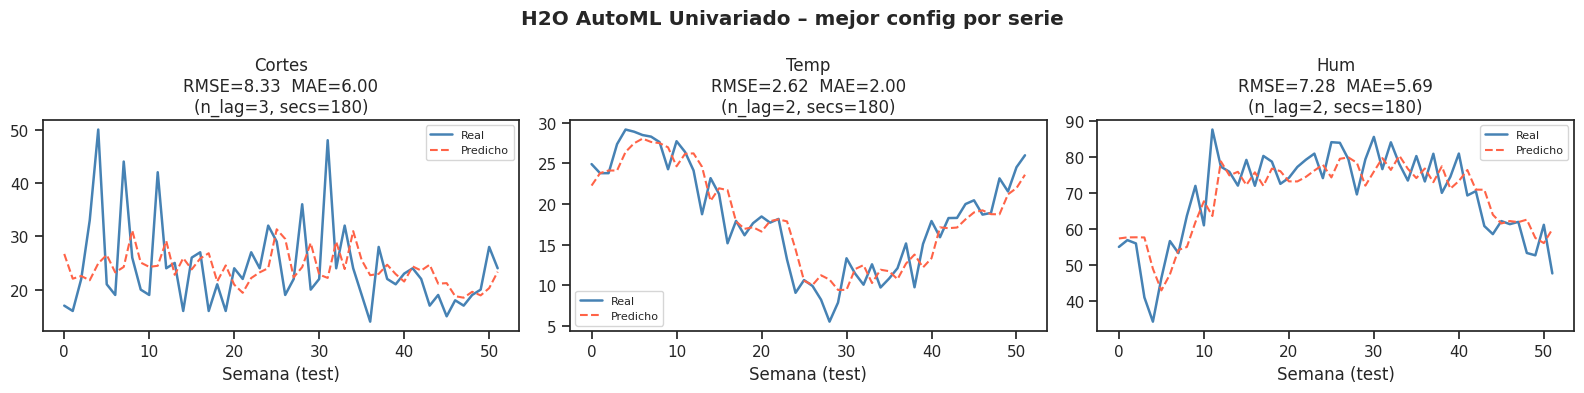

In [ ]:
combos   = list(itertools.product(GRID['n_lag'], GRID['max_secs']))
best_uni = {}
grid_uni = {}

for serie in ['Cortes', 'Temp', 'Hum']:
    print(f"\n▶ {serie}")
    resultados = []

    for n_lag, max_secs in combos:
        df_sup   = time_series_to_supervised(df[[serie]], n_lag=n_lag, target_col=serie)
        target   = f'{serie}(t+1)'
        N_TRAIN  = int(len(df_sup) * 0.80)
        df_train = df_sup.iloc[:N_TRAIN]
        df_test  = df_sup.iloc[N_TRAIN:]

        _, y_true, y_pred, rmse, mae = run_automl(df_train, df_test, target, max_secs)

        resultados.append({
            'serie': serie, 'n_lag': n_lag, 'max_secs': max_secs,
            'rmse': round(rmse, 4), 'mae': round(mae, 4),
            'y_true': y_true, 'y_pred': y_pred,
            'df_test_index': df_test.index,
        })
        print(f"    n_lag={n_lag}  max_secs={max_secs}  RMSE={rmse:.4f}  MAE={mae:.4f}")

    df_res = pd.DataFrame([{k: v for k, v in r.items()
                            if k not in ['y_true','y_pred','df_test_index']}
                           for r in resultados]).sort_values('rmse')
    grid_uni[serie] = df_res
    best_idx        = df_res.index[0]
    best_uni[serie] = resultados[best_idx]

    print(f"\n  ✓ Mejor: n_lag={best_uni[serie]['n_lag']}  "
          f"max_secs={best_uni[serie]['max_secs']}  "
          f"RMSE={best_uni[serie]['rmse']}")

# Tabla resumen
print("\n── Resumen Grid Search Univariado ──")
for serie in ['Cortes', 'Temp', 'Hum']:
    print(f"\n{serie}:")
    print(grid_uni[serie][['n_lag','max_secs','rmse','mae']].to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('H2O AutoML Univariado – mejor config por serie', fontweight='bold')
for ax, serie in zip(axes, ['Cortes', 'Temp', 'Hum']):
    r = best_uni[serie]
    ax.plot(r['y_true'], label='Real',     color='steelblue', lw=1.8)
    ax.plot(r['y_pred'], label='Predicho', color='tomato',    lw=1.5, linestyle='--')
    ax.set_title(f'{serie}\nRMSE={r["rmse"]:.2f}  MAE={r["mae"]:.2f}\n'
                 f'(n_lag={r["n_lag"]}, secs={r["max_secs"]})')
    ax.set_xlabel('Semana (test)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('automl_univariado_best.png', dpi=120, bbox_inches='tight')
plt.show()

El tiempo de búsqueda no tuvo impacto sobre el error: las configuraciones de 60 y 180 segundos produjeron resultados idénticos en todas las series. Esto indica que AutoML converge rápidamente con el tamaño muestral disponible, y que el tiempo adicional no permite explorar configuraciones sustancialmente distintas.

Segundo, el número de lags sí resulta determinante, particularmente en la serie Cortes. Pasar de 1 a 3 lags redujo el RMSE de 12.28 a 8.33, lo que sugiere que la serie de cortes presenta dependencias de corto plazo que se capturan mejor con más historia reciente. En cambio, Temp y Hum mostraron menor sensibilidad al número de lags, con diferencias marginales entre configuraciones.

## 4. Modelado Multivariado

En el enfoque multivariado, se incorporan como features los rezagos de las tres series simultáneamente, Cortes, Temp y Hum, manteniendo Cortes como variable objetivo. La hipótesis es que la temperatura y la humedad aportan información predictiva adicional sobre los cortes de energía, más allá de la propia historia de la serie.
Se aplica el mismo grid search que en el caso univariado: k ∈ {1, 2, 3} lags y tiempos de búsqueda de 60 y 180 segundos, seleccionando la configuración que minimiza el RMSE sobre el test.

  n_lag=1  max_secs=60  RMSE=8.0891  MAE=6.1127
  n_lag=1  max_secs=180  RMSE=8.0891  MAE=6.1127
  n_lag=2  max_secs=60  RMSE=7.9361  MAE=5.8621
  n_lag=2  max_secs=180  RMSE=7.9361  MAE=5.8621
  n_lag=3  max_secs=60  RMSE=7.9112  MAE=5.9163
  n_lag=3  max_secs=180  RMSE=7.9112  MAE=5.9163

── Resumen Grid Search Multivariado ──
 n_lag  max_secs  rmse    mae 
  3       180    7.9112 5.9163
  3        60    7.9112 5.9163
  2       180    7.9361 5.8621
  2        60    7.9361 5.8621
  1        60    8.0891 6.1127
  1       180    8.0891 6.1127

  ✓ Mejor: n_lag=3  max_secs=180  RMSE=7.9112


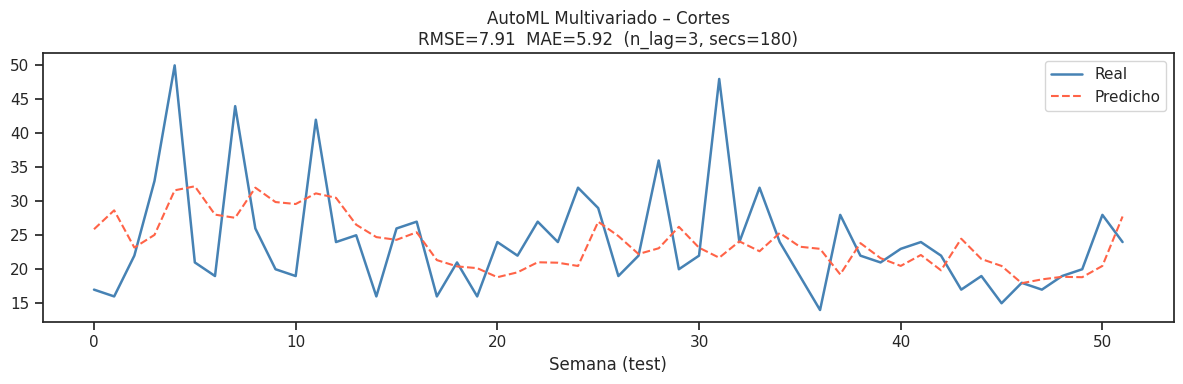

In [ ]:
resultados_multi = []
for n_lag, max_secs in combos:
    df_sup   = time_series_to_supervised(
        df[['Cortes','Temp','Hum']], n_lag=n_lag, target_col='Cortes')
    target   = 'Cortes(t+1)'
    N_TRAIN  = int(len(df_sup) * 0.80)
    df_train = df_sup.iloc[:N_TRAIN]
    df_test  = df_sup.iloc[N_TRAIN:]

    _, y_true, y_pred, rmse, mae = run_automl(df_train, df_test, target, max_secs)

    resultados_multi.append({
        'n_lag': n_lag, 'max_secs': max_secs,
        'rmse': round(rmse, 4), 'mae': round(mae, 4),
        'y_true': y_true, 'y_pred': y_pred,
        'df_test_index': df_test.index,
    })
    print(f"  n_lag={n_lag}  max_secs={max_secs}  RMSE={rmse:.4f}  MAE={mae:.4f}")

df_multi_res = pd.DataFrame([{k: v for k, v in r.items()
                               if k not in ['y_true','y_pred','df_test_index']}
                              for r in resultados_multi]).sort_values('rmse')
best_multi = resultados_multi[df_multi_res.index[0]]

print("\n── Resumen Grid Search Multivariado ──")
print(df_multi_res[['n_lag','max_secs','rmse','mae']].to_string(index=False))
print(f"\n  ✓ Mejor: n_lag={best_multi['n_lag']}  "
      f"max_secs={best_multi['max_secs']}  RMSE={best_multi['rmse']}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(best_multi['y_true'], label='Real',     color='steelblue', lw=1.8)
ax.plot(best_multi['y_pred'], label='Predicho', color='tomato',    lw=1.5, linestyle='--')
ax.set_title(f'AutoML Multivariado – Cortes\nRMSE={best_multi["rmse"]:.2f}  '
             f'MAE={best_multi["mae"]:.2f}  '
             f'(n_lag={best_multi["n_lag"]}, secs={best_multi["max_secs"]})')
ax.set_xlabel('Semana (test)')
ax.legend()
plt.tight_layout()
plt.savefig('automl_multivariado_best.png', dpi=120, bbox_inches='tight')
plt.show()

Al igual que en el caso univariado, el tiempo de búsqueda no tuvo impacto sobre el error: 60 y 180 segundos produjeron resultados idénticos en todas las configuraciones, confirmando que AutoML converge rápidamente con este tamaño muestral.

El número de lags sí muestra una leve mejora progresiva: pasar de n_lag=1 (RMSE=8.09) a n_lag=3 (RMSE=7.91) redujo el error marginalmente. A diferencia del caso univariado de Cortes, donde la ganancia fue más pronunciada (de 12.28 a 8.33), aquí la incorporación de historia adicional aporta menos.

## 5. Comparación de performance out of sample del modelado Univariado vs Multivariado





Ambas configuraciones convergen en los mismos hiperparámetros óptimos (n_lag=3, 180 segundos), lo que refuerza que la dependencia temporal de corto plazo es la señal más relevante independientemente de si se incorporan variables exógenas o no.

In [ ]:
r_uni   = best_uni['Cortes']
r_multi = best_multi

In [ ]:
print(f"  Univariado  → RMSE={r_uni['rmse']:.4f}  MAE={r_uni['mae']:.4f}  "
      f"(n_lag={r_uni['n_lag']}, secs={r_uni['max_secs']})")
print(f"  Multivariado→ RMSE={r_multi['rmse']:.4f}  MAE={r_multi['mae']:.4f}  "
      f"(n_lag={r_multi['n_lag']}, secs={r_multi['max_secs']})")

  Univariado  → RMSE=8.3261  MAE=5.9961  (n_lag=3, secs=180)
  Multivariado→ RMSE=7.9112  MAE=5.9163  (n_lag=3, secs=180)


In [ ]:
ganador = 'Univariado' if r_uni['rmse'] <= r_multi['rmse'] else 'Multivariado'
print(f"\n  ✓ Ganador para Cortes: {ganador}")


  ✓ Ganador para Cortes: Multivariado


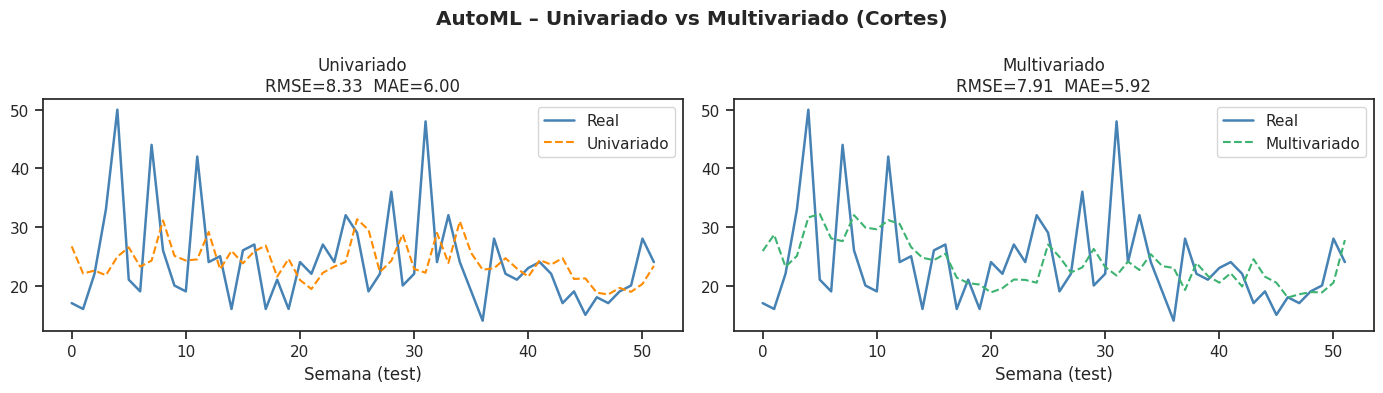

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('AutoML – Univariado vs Multivariado (Cortes)', fontweight='bold')
for ax, (label, r, color) in zip(axes, [
    ('Univariado',   r_uni,   'darkorange'),
    ('Multivariado', r_multi, 'mediumseagreen'),
]):
    ax.plot(r['y_true'], label='Real',  color='steelblue', lw=1.8)
    ax.plot(r['y_pred'], label=label,   color=color,       lw=1.5, linestyle='--')
    ax.set_title(f'{label}\nRMSE={r["rmse"]:.2f}  MAE={r["mae"]:.2f}')
    ax.set_xlabel('Semana (test)')
    ax.legend()
plt.tight_layout()
plt.savefig('automl_uni_vs_multi.png', dpi=120, bbox_inches='tight')
plt.show()

El modelo multivariado obtiene un RMSE de 7.91 frente a 8.33 del univariado, una mejora del 5% aproximadamente. Si bien la diferencia es estadísticamente modesta, visualmente se observa que el multivariado muestra mayor amplitud en sus predicciones, se aproxima mejor a algunos picos de las primeras semanas del test,mientras que el univariado tiende a una línea más plana y conservadora.
Sin embargo, ambos modelos comparten la misma limitación estructural: ninguno logra anticipar los picos extremos de la serie. Los valores reales superiores a 40 cortes son sistemáticamente subestimados, lo que refleja que AutoML, al optimizar el error cuadrático medio, penaliza por igual todos los errores sin priorizar la detección de eventos atípicos.

## 6.Guardado final

Se exportan las predicciones del conjunto de test (20% final) para cada serie: modelos univariados (Cortes, Temp, Hum) y el modelo multivariado (Cortes ~ Temp + Hum). Incluye valores reales (y_true), predicciones (y_pred) y métricas (RMSE, MAE). Los resultados corresponden a los modelos optimizados por Grid Search.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/SDT/Resultados"
os.makedirs(BASE_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
all_preds   = []
all_metrics = []

for serie in ['Cortes', 'Temp', 'Hum']:
    r = best_uni[serie]
    all_preds.append(pd.DataFrame({
        'model' : 'AutoML_Uni',
        'serie' : serie,
        'date'  : r['df_test_index'],
        'y_true': r['y_true'],
        'y_pred': r['y_pred'],
    }))
    all_metrics.append({
        'model': 'AutoML_Uni', 'serie': serie,
        'rmse' : r['rmse'],    'mae'  : r['mae'],
        'n_lag': r['n_lag'],   'max_secs': r['max_secs'],
    })

all_preds.append(pd.DataFrame({
    'model' : 'AutoML_Multi',
    'serie' : 'Cortes (Temp+Hum)',
    'date'  : best_multi['df_test_index'],
    'y_true': best_multi['y_true'],
    'y_pred': best_multi['y_pred'],
}))
all_metrics.append({
    'model': 'AutoML_Multi', 'serie': 'Cortes (Temp+Hum)',
    'rmse' : best_multi['rmse'], 'mae': best_multi['mae'],
    'n_lag': best_multi['n_lag'], 'max_secs': best_multi['max_secs'],
})

pd.concat(all_preds).to_csv(
    f"{BASE_PATH}/predictions_AutoML.csv", index=False)
pd.DataFrame(all_metrics).to_csv(
    f"{BASE_PATH}/metrics_AutoML.csv", index=False)

print("\n✔ AutoML guardado correctamente")
print(pd.DataFrame(all_metrics)[['model','serie','rmse','mae','n_lag']])

h2o.cluster().shutdown()


✔ AutoML guardado correctamente
      model           serie          rmse     mae   n_lag
0    AutoML_Uni             Cortes  8.3261  5.9961    3  
1    AutoML_Uni               Temp  2.6153  2.0009    2  
2    AutoML_Uni                Hum  7.2775  5.6944    2  
3  AutoML_Multi  Cortes (Temp+Hum)  7.9112  5.9163    3  
H2O session _sid_a841 closed.
